# Übung 6

**Gruppenname:**

*TKKR*

Gehen Sie wie folgt vor:

1. Bitte benennen Sie jetzt dieses Jupyter Notebook um (z.B. über `File -> Rename`):

   Namensschema: `Gruppenname-X`. Ersetzen Sie "X" mit der oben angegebenen Nummer der Übung.

   - Beispiel 1: Team REZA bearbeitet Übung 2. Das Notebook heißt: REZA-2.
   - Beispiel 2: Sie sind keinem Team zugeordnet (nicht empfehlenswert) und bearbeiten Übung 2: Ihr Notebook heißt: Nachname-2.


2. Tragen Sie Ihren Gruppennamen auch ganz oben bei "Name Ihrer Gruppe" ein.

3. Bearbeiten Sie dann dieses Notebook. Vergessen Sie dabei nicht, das Jupyter Notebook regelmäßig zu speichern (z.B. über `Strg + S` oder über `File -> Save and Checkpoint`).

### In dieser Übung ...
... werden wir die lineare Regression implementieren und anwenden (Übung 6.1). Daneben werden wir feststellen, dass Klassifikation und Regression zwar unterschiedliche Ziele verfolgen, sich aber für den anderen Zweck jeweils einsetzen lassen (Übung 6.3, 6.4). Dabei wird uns ein synthetischer Datensatz beim Verständnis helfen (Übungen 6.2).

### 6.1 Profitvorhersage für ein Franchise-Unternehmen (Lineare Regression)
Ein Unternehmen hat ein Systemgastronomiekonzept mit Imbisswagen entwickelt und in verschiedenen Städten ausprobiert. Die Daten, die in dieser Entwicklungsphase erhoben wurden, sollen dazu genutzt werden, um erzielbare Profite an verschiedenen potenziellen Standorten (Städten) vorherzusagen. Diese Vorhersagen sollen der Unternehmensführung dazu dienen, in besonders gewinnträchtigen Städten gezielt um Franchisenehmer zu werben. Dabei interessiert sich das Unternehmen besonders für die Profitchancen in kleinen und mittelgroßen Städten.

**Daten:**

Die Daten enthalten ein Feature (die Anzahl der Einwohner einer Stadt \[in Einheiten von 10000 Einwohnern\]) und ein Label (der erzielte Gewinn pro Imbisswagen in der Stadt \[in Einheiten von 10000 Euro\]).

**Ihre Aufgaben:**

(1) Importieren Sie die Daten und visualisieren Sie in einem Scatterplot den erzielten Gewinn pro Imbisswagen (y-Achse) und die Anzahl der Einwohner der Stadt (x-Achse). Beschriften Sie die Achsen und machen Sie sich noch einmal klar, in welchen Einheiten die Daten vorliegen.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

# Sie finden diese Daten auch zum Download unter: https://data.bialonski.de/ml/franchise-data.txt
data = np.loadtxt('https://data.bialonski.de/ml/franchise-data.txt', delimiter=',')
# data[:,0] -> Populationsgröße [in Einheiten von 10000]
# data[:,1] -> Profit pro Imbisswagen [in Einheiten von 10000 Euro]

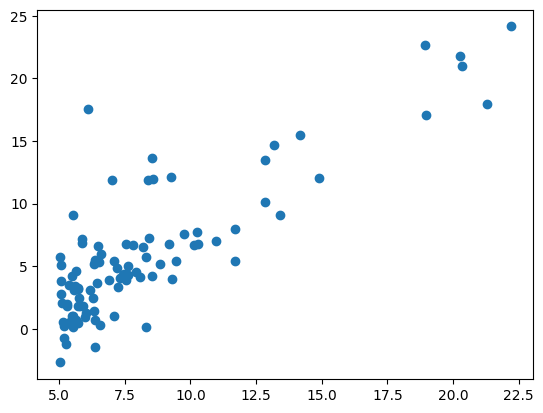

In [2]:
plt.scatter(data[:, 0], data[:, 1])
plt.show()

(2) Implementieren Sie den "Algorithmus" für *lineare Regression*, wie Sie ihn in der Vorlesung kennengelernt haben. Ihre Funktion nimmt Features und Labels entgegen, konstruiert die Matrizen $\text{X}$ und $\text{X}^\dagger$, und gibt die finale Hypothese, also den finalen Vektor $w_\text{lin}$, zurück.

In [3]:
def lin_reg(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    X = np.column_stack((np.ones(x.shape[0]), x))
    X_pinv = np.linalg.inv(X.T @ X) @ X.T
    return X_pinv @ y

In [4]:
w_lin = lin_reg(data[:, 0], data[:, 1])

In [5]:
def predict(x: np.typing.ArrayLike):
    x = np.array(x)
    X = np.column_stack((np.ones(x.shape[0]), x))
    return X @ w_lin

(3) Visualisieren Sie nun in einem Scatterplot sowohl die Daten als auch die finale Hypothese, d.h. die durch $w_\text{lin}$ definierte Gerade.

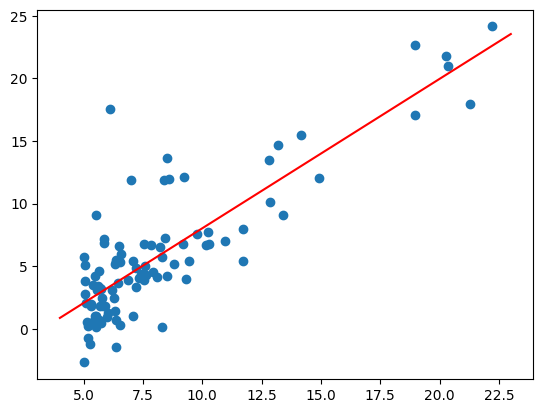

In [6]:
plt.scatter(data[:, 0], data[:, 1])
plt.plot([4, 23], [predict([4]), predict([23])], 'r')
plt.show()

(4) Nutzen Sie Ihr Modell, um die Profitchancen für eine Stadt mit 35000 Einwohnern sowie mit 70000 Einwohnern vorherzusagen. Geben Sie Ihre vorhergesagten Profite an.

In [7]:
einwohner1 = 35000
print(f"Die Profitchancen für eine Stadt mit {einwohner1} Einwohnern ist {predict([einwohner1])[0]}")

einwohner2 = 70000
print(f"Die Profitchancen für eine Stadt mit {einwohner2} Einwohnern ist {predict([einwohner2])[0]}")

Die Profitchancen für eine Stadt mit 35000 Einwohnern ist 41752.281765757536
Die Profitchancen für eine Stadt mit 70000 Einwohnern ist 83508.45931239339


### 6.2 Ein synthetischer Datensatz: Halbkreise

Wir implementieren in dieser Übung einen synthetischen Datensatz, mit dem wir die Untersuchungen in den unten stehenden Übungen durchführen werden.

**Bitte beachten Sie:**

* Sie zählen sich zu den 20% der Vorlesungsteilnehmer, die am fittesten in Python sind? Dann ist die Implementierung dieses synthetischen Datensatzes für Sie eine Fingerübung. Bitte bearbeiten Sie diese Aufgabe.
* Sie haben bereits einen Machine Learning Kurs im Rahmen Ihres Bachelor-Studiums absolviert? Dann sind Sie gut vorbereitet und bearbeiten bitte diese Aufgabe.
* Sie kämpfen an verschiedenen Fronten, um Python zu lernen, während Sie gleichzeitig den Vorlesungsstoff versuchen zu verinnerlichen? Dann möchte ich Sie ermutigen: Kämpfen Sie weiter und überspringen Sie diese Übung 6.2, um sich etwas mehr Zeit zu verschaffen. Nutzen Sie in den späteren Übungsteilen meine Implementierung dieses synthetischen Datensatzes, die Sie [hier](https://data.bialonski.de/ml/semi-circle-dataset.py) herunterladen können.

Wir erzeugen einen synthetischen Datensatz, dessen Datenpunkte uniform in zwei Halbkreisen verteilt sind:

<img src="https://data.bialonski.de/ml/figure-semi-circle.png" style="width:50%">

Die (roten) Punkte des oberen Halbkreises besitzen jeweils das Label "-1"; die (blauen) Punkte des unteren Halbkreises besitzen jeweils das Label "+1". Der Mittelpunkt des oberen Kreises fällt mit der Mitte der Kante des unteren Halbkreises zusammen.

**Ihre Aufgabe**

(1) Schreiben Sie eine Funktion, die die Anzahl der gewünschten Datenpunkte $N$, den Radius $r$, die Breite $b$ und die Distanz $d$ der beiden Halbkreise entgegennimmt und die zufälligen Koordinaten der Datenpunkte sowie ihre Labels zurückgibt. Stellen Sie dabei sicher, dass der obere Halbkreis und der untere Halbkreis jeweils $\frac{N}{2}$ Datenpunkte enthalten.

In [8]:
import math


def make_shifted_circle(N: int, r: float, b: float, d: float, shuffle_arrays=True) -> tuple[np.ndarray, np.ndarray]:
    vert_dist = d
    horiz_dist = r + b/2.0
    angles_neg = np.random.rand(math.ceil(N/2.0)) * np.pi
    angles_pos = np.random.rand(math.floor(N/2.0)) * -np.pi
    radius_neg = np.random.rand(math.ceil(N/2.0)) * b + r
    radius_pos = np.random.rand(math.floor(N/2.0)) * b + r
    X_neg = np.array([radius_neg * np.cos(angles_neg), radius_neg * np.sin(angles_neg)]).T
    X_pos = np.array([radius_pos * np.cos(angles_pos), radius_pos * np.sin(angles_pos)]).T
    X_pos[:, 0] += horiz_dist
    X_pos[:, 1] -= vert_dist
    y_neg = np.ones(X_neg.shape[0]) * -1
    y_pos = np.ones(X_pos.shape[0])
    X = np.r_[X_neg, X_pos]
    y = np.r_[y_neg, y_pos]
    if shuffle_arrays:
        argshuffle = np.random.choice(np.arange(N), N)
        X = X[argshuffle]
        y = y[argshuffle]
    return X, y

(2) Visualisieren Sie in einem Scatterplot einen zufälligen Datensatz mit $N=2000$, $d=-5$, $r=10$, $b=5$.

(2000, 2)
[-1.  1. -1. ...  1. -1. -1.]


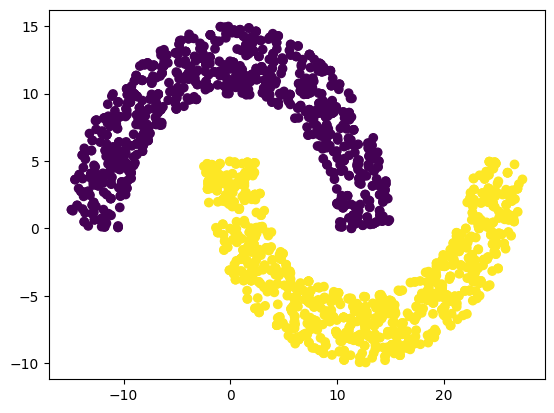

In [9]:
X, y = make_shifted_circle(2000, 10, 5, -5)
print(X.shape)
print(y)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

(3) Ist der so generierte Datensatz linear separierbar? (ja/nein)

Nein

(4) Welcher Parameter bestimmt, ob die Daten linear separierbar sind? (1 Satz)

d bestimmt, ob die Daten linear separierbar sind. 

Ist d > 0, dann sind sie linear separierbar.

### 6.3 Regression für ein Klassifikationsproblem (Teil 1): Lineare Separierbarkeit

* Für diese Übung benötigen Sie Code, den Sie in Übung 6.1 und 6.2 erzeugt haben. Daneben benötigen Sie Code für PLA, den Sie in einer der vorherigen Übungen bereits geschrieben haben.

**Ihre Aufgaben:**

(1) Erzeugen Sie einen Datensatz mit dem Code aus Übung 6.2 mit folgenden Werten: $N=2000$, $r=10$, $b=5$, $d=5$.

In [10]:
X, y = make_shifted_circle(2000, 10, 5, 5)

(2) Nutzen Sie PLA, um eine finale Hypothese ($\mathbf{w}_\text{PLA}$) zu erzeugen, die die beiden Klassen voneinander trennt.

In [11]:
def h(x: np.ndarray, w: np.ndarray):
    return np.sign(x.dot(w))


def pla(X, y, w, verbose=False):
    X_stacked = np.hstack((np.ones(((X.shape[0], 1))), X))
    w_trace = []
    w_final = _pla_help(X_stacked, y, w, w_trace)
    if verbose:
        return w_final, w_trace
    return w_final


def _pla_help(X_stacked, y, w, w_trace):
    y_pred = h(X_stacked, w)
    bools = y_pred == y
    if np.all(bools):
        return w
    idx = np.argmin(bools)
    x_t = X_stacked[idx]
    y_t = y[idx]
    w_next = w + y_t * x_t
    w_trace.append(w_next)
    return _pla_help(X_stacked, y, w_next, w_trace)


def g(x_1, w):
    return (w[0] + w[1] * x_1) / (-w[2])

In [12]:
w_pla = pla(X, y, np.zeros(X.shape[1] + 1))

(3) Wenden Sie lineare Regression (Ihr Code aus Übung 6.1) auf denselben Datensatz an und erhalten Sie die finale Hypothese $\mathbf{w}_\text{lin}$.

In [13]:
w_lin = lin_reg(X[:, 0], X[:, 1])

In [14]:
w_lin_2d = lin_reg(X, y)

(4) Visualisieren Sie den Datensatz samt der durch die lineare Regression erzeugten Gerade sowie der durch PLA erzeugten Gerade.

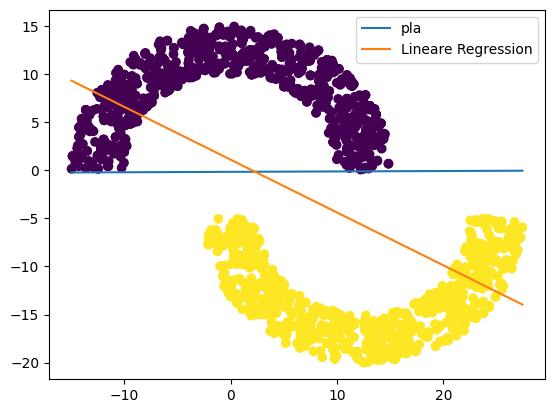

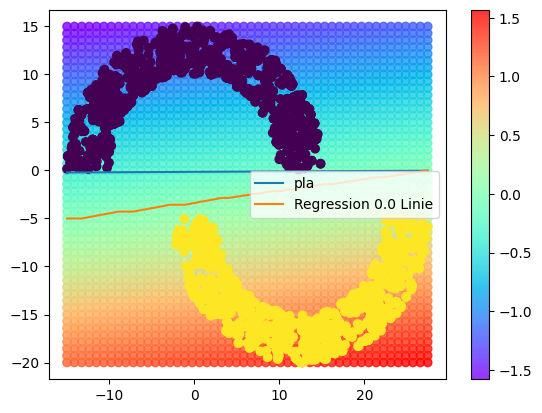

In [15]:
plt.scatter(X[:, 0], X[:, 1], c=y)
x_space = np.linspace(np.min(X[:, 0]), np.max(X[:, 0]))
plt.plot(x_space, g(x_space, w_pla), label="pla")
plt.plot(x_space, predict(x_space), label="Lineare Regression")

plt.legend()
plt.show()

_, ax = plt.subplots()

y_space = np.linspace(np.min(X[:, 1]), np.max(X[:, 1]))
x_grid, y_grid = np.meshgrid(x_space, y_space)
x_grid = x_grid.ravel()
y_grid = y_grid.ravel()
z_grid = np.c_[np.ones(x_grid.shape[0]), x_grid, y_grid] @ w_lin_2d
plt.scatter(x_grid, y_grid, c=z_grid, cmap='rainbow', alpha=0.8)
plt.colorbar()
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.plot(x_space, g(x_space, w_pla), label="pla")
plt.plot(x_grid[np.abs(z_grid) < 1e-2], y_grid[np.abs(z_grid) < 1e-2], label="Regression 0.0 Linie")
plt.legend()
plt.show()

(5) Beschreiben Sie, was Sie in Ihrer Abbildung sehen (1-3 Sätze). Welche Gemeinsamkeiten, welche konzeptionellen Unterschiede zwischen PLA und linearer Regression fallen Ihnen auf? (Tipp: Eindeutigkeit der Lösung?)

Im oberen Plot sind PLA und die Lineare Regression sehr unähnlich. Die Regression berechnet nur die $x_2$ Komponente des Datensatzes, während die PLA die Datensätze in Klassen unterteilt, also die Labels berechnet.

Im unteren Plot dagegen, ähneln sich die Ergebnisse der Regression und der PLA. Die Regression berechnet hierbei nämlich abhängig von $x_1$ und $x_2$ das Label, ähnlich wie die PLA, nur in reellen Zahlen. Ein Unterschied im Verlauf der 0.0 Linie der Regression und der PLA Linie ist die Steigung. Die 0.0 Linie hat eine höhere Steigung, da sie nicht nur versucht die Klassen zu trennen, sondern auch die Werte zwischen den Klassen zu interpolieren.

(6) Optional: Erstellen Sie eine 3D-Visualisierung der Daten und Ihrer Hypothesen für den PLA und die lineare Regression. Die dritte Dimension ergibt sich dabei aus den Labels der Datenpunkte, bzw. der Vorhersagen der Hypothesen.

**Hinweis:**
* Sie können die folgende Funktion nutzen, um die Entscheidungsflächen der Hypothesen zu visualisieren: `plot_surface`, deren Verwendung [hier](https://matplotlib.org/stable/gallery/mplot3d/surface3d.html) veranschaulicht wird.
* Für die Erstellung der Entscheidungsflächen erzeugen Sie sich am besten ein Gitter aus $x$- und $y$-Koordinaten, das die Fläche abdeckt, die Sie visualisieren möchten. Dieses Gitter können Sie dann in die Hypothesen einsetzen, um die Entscheidungsflächen zu berechnen.

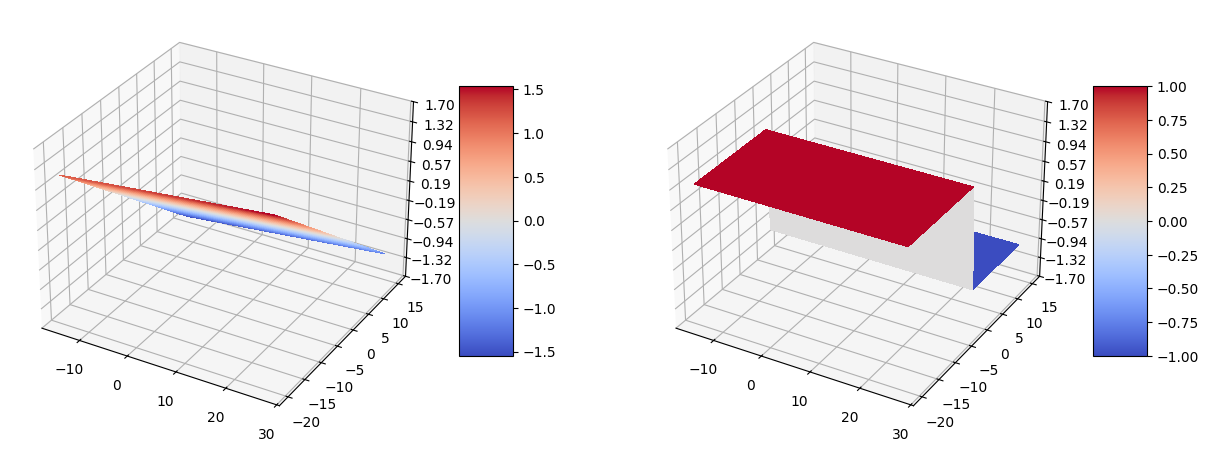

In [16]:
from matplotlib.ticker import LinearLocator
from matplotlib import cm
fig, ax = plt.subplots(1, 2, subplot_kw={"projection": "3d"}, figsize=(15, 7))
ax = ax.flatten()

x_grid, y_grid = np.meshgrid(x_space, y_space)
space_matrix = np.c_[np.ones(x_grid.ravel().shape[0]), x_grid.ravel(), y_grid.ravel()]

reg_z = space_matrix @ w_lin_2d
pla_z = h(space_matrix, w_pla)

surf1 = ax[0].plot_surface(x_grid, y_grid, reg_z.reshape(x_grid.shape), cmap=cm.coolwarm, linewidth=0, antialiased=False)
surf2 = ax[1].plot_surface(x_grid, y_grid, pla_z.reshape(x_grid.shape), cmap=cm.coolwarm, linewidth=0, antialiased=False)

# Customize the z axis.
ax[0].set_zlim(-1.7, 1.7)
ax[1].set_zlim(-1.7, 1.7)
ax[0].zaxis.set_major_locator(LinearLocator(10))
ax[1].zaxis.set_major_locator(LinearLocator(10))
# A StrMethodFormatter is used automatically
ax[0].zaxis.set_major_formatter('{x:.02f}')
ax[1].zaxis.set_major_formatter('{x:.02f}')

# Add a color bar which maps values to colors.
fig.colorbar(surf1, shrink=0.5, aspect=5)
fig.colorbar(surf2, shrink=0.5, aspect=5)
plt.show()

### 6.4 Regression für ein Klassifikationsproblem (Teil 2): Nicht linear separierbare Daten

In der vorherigen Übung haben wir es mit einem linear separierbaren Datensatz zu tun. Das werden wir jetzt ändern. Wir wollen die Performanz von linearer Regression und Pocket miteinander vergleichen. Unsere Vergleichsparameter sind "Ausführungsdauer" und In-Sample-Fehler.

**Hinweis:**
* Für diese Übung wollen wir die Ausführungszeiten der Codezellen messen. Dazu können Sie den [Magic Command](https://ipython.readthedocs.io/en/stable/interactive/magics.html) `%%time` verwenden. Dieser wird zu Beginn einer Codezelle eingegeben und misst die Ausführungszeit dieser Codezelle.
* **Bevor Sie fortfahren:** Sollten Sie einmal aus Versehen eine Endlosschleife bauen oder Sie wollen Ihren Algorithmus terminieren, dann wird das Schließen des Browserfensters den Rechenprozess (den Kernel) nicht stoppen. Er wird auf dem Server weiterlaufen. Stattdessen sollten Sie in diesem Fall den Kernel dieses *Jupyter Notebooks* stoppen durch das Menü `Kernel -> Interrupt` oder durch die Tastatur mit: `ESC` (Wechsel in den Command-Mode) und dann zweimal die Taste `i` drücken. Wenn Sie sich für weitere Informationen zu *Jupyter Notebook* interessieren, schauen Sie auch gerne nochmal in das Jupyter Tutorial im Übungsmodul ("Vorbereitungen").

**Ihre Aufgaben:**

(1) Erzeugen Sie einen Datensatz mit dem Code aus Übung 6.2 mit folgenden Werten: $N=2000$, $r=10$, $b=5$, $d=-5$.

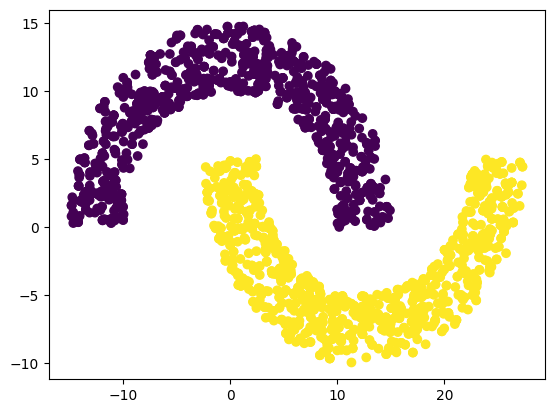

In [17]:
X_insep, y_insep = make_shifted_circle(2000, 10, 5, -5)
plt.scatter(X_insep[:, 0], X_insep[:, 1], c=y_insep)
plt.show()

(2) Nutzen Sie den Pocket-Algorithmus, um eine finale Hypothese ($\mathbf{w}_\text{POC}$) zu erzeugen, die die beiden Klassen voneinander trennt. Messen Sie dabei die Ausführungszeit des Algorithmus.
   * **Hinweis zur Wahl der maximalen Iterationsanzahl $T$:** Da ich vor Übungsbeginn nicht die Gelegenheit hatte, die Performanz des JupyterHub-Servers zu testen, weiß ich nicht, wie lange Ihre Pocket-Implementierung auf dem synthetischen Datensatz braucht, um eine bestimmte Iterationsanzahl $T$ durchzuarbeiten. Eine Iterationszahl von $T=100000$ (hunderttausend) wäre gut. Messen Sie zunächst die Ausführungsdauer für kleinere Werte von $T$ (z.B. $T=1000$), um die Laufzeit für hunderttausend Iterationsschritte abschätzen zu können. Wählen Sie dann eine möglichst hohe Zahl $T\leq 100000$, die es Ihnen erlaubt, den Pocket-Lernprozess innerhalb von höchstens 5 Minuten zu einem Abschluss zu bringen.

In [18]:
def pla_pocket(x: np.ndarray, y: np.ndarray, iterations: int):
    x_stacked = np.hstack((np.ones(((x.shape[0], 1))), x))
    w_best = np.zeros(x_stacked.shape[1])
    w_curr = w_best.copy()
    bools_curr = h(x_stacked, w_best) != y
    err = np.sum(bools_curr) / bools_curr.shape[0]
    i = 0
    while i < iterations and err > 0:
        idx = bools_curr.argmax()
        x_k = x_stacked[idx]
        y_k = y[idx]
        w_curr = w_curr + y_k * x_k
        bools_curr = h(x_stacked, w_curr) != y
        err_temp = np.sum(bools_curr) / bools_curr.shape[0]
        if err_temp < err:
            w_best = w_curr.copy()
            err = err_temp
        i += 1
    return w_best

In [19]:
%%time

w_pocket = pla_pocket(X_insep, y_insep, 1000000)

CPU times: total: 13.8 s
Wall time: 14 s


(3) Notieren Sie sich die angezeigte Zeitdauer, den Ihr Pocket-Algorithmus für die Generierung der finalen Hypothese gebraucht hat.

Mein Pocket Algorithmus hat für Hunderttausend Iterationen etwa 14 s gebraucht.

(4) Bestimmen Sie den In-Sample Fehler $E_\text{in}$ (also den Klassifikationsfehler) für die finale Hypothese von Pocket.

In [20]:
e_in = (h(np.c_[np.ones(X_insep.shape[0]), X_insep], w_pocket) == y_insep).sum() / y_insep.shape[0]
print(f"In-Sample Fehler: {e_in}")

In-Sample Fehler: 0.905


(5) Nutzen Sie Ihren Code aus Übung 6.1 und führen eine lineare Regression auf demselben Datensatz durch. Messen Sie dabei ebenfalls die Ausführungsdauer und bestimmen Sie den In-Sample-Fehler (**Klassifikations**fehler!) $E_\text{in}$ für die finale Hypothese ($\mathbf{w}_\text{lin}$) der linearen Regression.

In [21]:
%%time

w_lin_2 = lin_reg(X_insep, y_insep)

CPU times: total: 0 ns
Wall time: 230 μs


Der Algorithmus hat ca. 230 Mikrosekunden gebraucht.

(6) Visualisieren Sie den Datensatz sowie die finalen Hypothesen (also Geraden) $\mathbf{w}_\text{POC}$ und $\mathbf{w}_\text{lin}$.

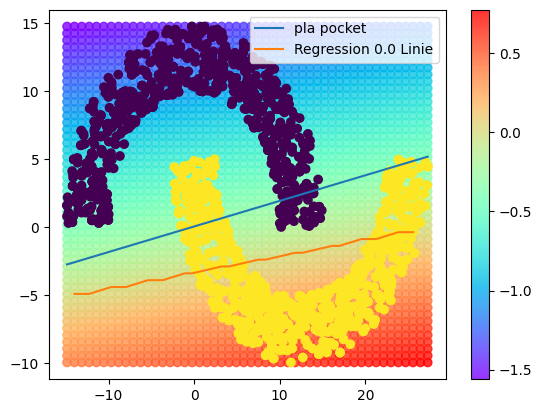

In [22]:
x_space = np.linspace(np.min(X_insep[:, 0]), np.max(X_insep[:, 0]))

_, ax = plt.subplots()

y_space = np.linspace(np.min(X_insep[:, 1]), np.max(X_insep[:, 1]))
x_grid, y_grid = np.meshgrid(x_space, y_space)
x_grid = x_grid.ravel()
y_grid = y_grid.ravel()
z_grid = np.c_[np.ones(x_grid.shape[0]), x_grid, y_grid] @ w_lin_2d
plt.scatter(x_grid, y_grid, c=z_grid, cmap='rainbow', alpha=0.8)
plt.colorbar()
plt.scatter(X_insep[:, 0], X_insep[:, 1], c=y_insep)
plt.plot(x_space, g(x_space, w_pocket), label="pla pocket")
plt.plot(x_grid[np.abs(z_grid) < 1e-2], y_grid[np.abs(z_grid) < 1e-2], label="Regression 0.0 Linie")
plt.legend()
plt.show()

(7) Vergleichen Sie lineare Regression und Pocket miteinander, indem Sie Ihre Ergebnisse für $E_\text{in}$ und die Ausführungszeiten (Execution Times) miteinander vergleichen. Welche Vor- und Nachteile fallen Ihnen ein, wenn Sie lineare Regression für Klassifikationsprobleme einsetzen? (1-3 Sätze).

Die 0.0 Linie und die Entscheidungslinie der Pocket-PLA sind erneut unähnlich. Dabei trennt die PLA Linie die Daten besser, als die 0.0 Linie. Das liegt daran, dass die PLA Linie nur zwischen -1 und 1 unterscheiden muss, während die Regression versucht alle reellen Zahlen abzubilden. Die Regression ist zwar viel schneller, liefert aber in der Klassifizierung keine besseren Ergebnisse, als ein Perzeptron.